Import Libraries




In [30]:
# استيراد كل المكتبات اللي رح نحتاجها
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# مكتبات النماذج
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# مكتبات التقييم
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,confusion_matrix, classification_report,precision_recall_curve, brier_score_loss,ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve



In [31]:
# Load Dataset
df = pd.read_csv('data/engineered_data.csv')

# Clean column names (some columns may contain extra spaces)
df.columns = df.columns.str.strip()

# Display dataset information
print("Dataset Shape:", df.shape)

print("\nFirst 3 Rows:")
df.head(3)

Dataset Shape: (38462, 71)

First 3 Rows:


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,sentiment_score,title_content_ratio,self_ref_ratio,kw_subjectivity,polarity_gap,complexity_score,log_n_tokens_content,log_num_hrefs,log_num_imgs,log_kw_avg_avg
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.048282,0.054545,0.997988,2.608086,1.300,114.234155,5.393628,1.609438,0.693147,7.196752
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.050828,0.035156,0.000000,1.364983,0.825,87.017677,5.545177,1.386294,0.693147,7.196752
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.222006,0.042453,0.998912,4.119701,1.800,144.876148,5.356586,1.386294,0.693147,7.196752


Target

Median Shares: 1400.0

Class Distribution:
popular
1    20463
0    17999
Name: count, dtype: int64

Popular Articles Ratio: 53.2%


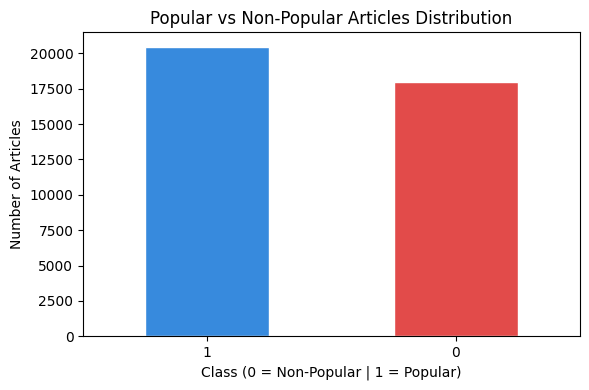

In [32]:
# Create Binary Target Variable

median_shares = df['shares'].median()
print(f"Median Shares: {median_shares}")

df['popular'] = (df['shares'] >= median_shares).astype(int)

# Class Distribution
print("\nClass Distribution:")
print(df['popular'].value_counts())

print(f"\nPopular Articles Ratio: {df['popular'].mean() * 100:.1f}%")

# Plot Class Distribution
plt.figure(figsize=(6, 4))

df['popular'].value_counts().plot(
    kind='bar',
    color=['#378ADD', '#E24B4A'],
    edgecolor='white'
)

plt.title('Popular vs Non-Popular Articles Distribution')
plt.xlabel('Class (0 = Non-Popular | 1 = Popular)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [33]:
# Remove non-feature columns (URL, original target, and new target)
cols_to_drop = ['shares', 'popular','log_shares']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df['popular']


print(f"Number of Features: {X.shape[1]}")
print(f"Number of Rows: {X.shape[0]}")

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,          # Ensures reproducible results
    stratify=y           )    # Preserves class distribution
print(f"\nTraining Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

# Feature Scaling
# Important for Logistic Regression, KNN, and SVM
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)



Number of Features: 68
Number of Rows: 38462

Training Set Shape: (30769, 68)
Testing Set Shape: (7693, 68)


Train each model

In [34]:
for name, model in models.items():
    print(f"Training {name}...")
    
    if name in ['Logistic Regression', 'KNN', 'SVM (Linear)', 'SVM (RBF)']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob),
        'brier': brier_score_loss(y_test, y_prob)
    }
    print(f"{name} - Accuracy: {results[name]['accuracy']:.3f} | F1: {results[name]['f1']:.3f}")

Training Logistic Regression...
Logistic Regression - Accuracy: 0.652 | F1: 0.680
Training KNN...
KNN - Accuracy: 0.609 | F1: 0.625
Training SVM (Linear)...
SVM (Linear) - Accuracy: 0.651 | F1: 0.679
Training SVM (RBF)...
SVM (RBF) - Accuracy: 0.664 | F1: 0.692
Training Decision Tree...
Decision Tree - Accuracy: 0.582 | F1: 0.604
Training Random Forest...
Random Forest - Accuracy: 0.668 | F1: 0.696
Training XGBoost...
XGBoost - Accuracy: 0.661 | F1: 0.685


Comparison Table

Model Comparison:
                    Accuracy Precision Recall F1-Score AUC-ROC Brier Score
XGBoost                0.661     0.677  0.694    0.685   0.722       0.215
Logistic Regression    0.652     0.666  0.693    0.680   0.709       0.217
KNN                    0.609     0.638  0.612    0.625   0.648       0.256
SVM (Linear)           0.651     0.665  0.694    0.679   0.704       0.218
SVM (RBF)              0.664     0.675  0.710    0.692   0.719       0.213
Decision Tree          0.582     0.608  0.600    0.604   0.580       0.418
Random Forest          0.668     0.678  0.715    0.696   0.722       0.212


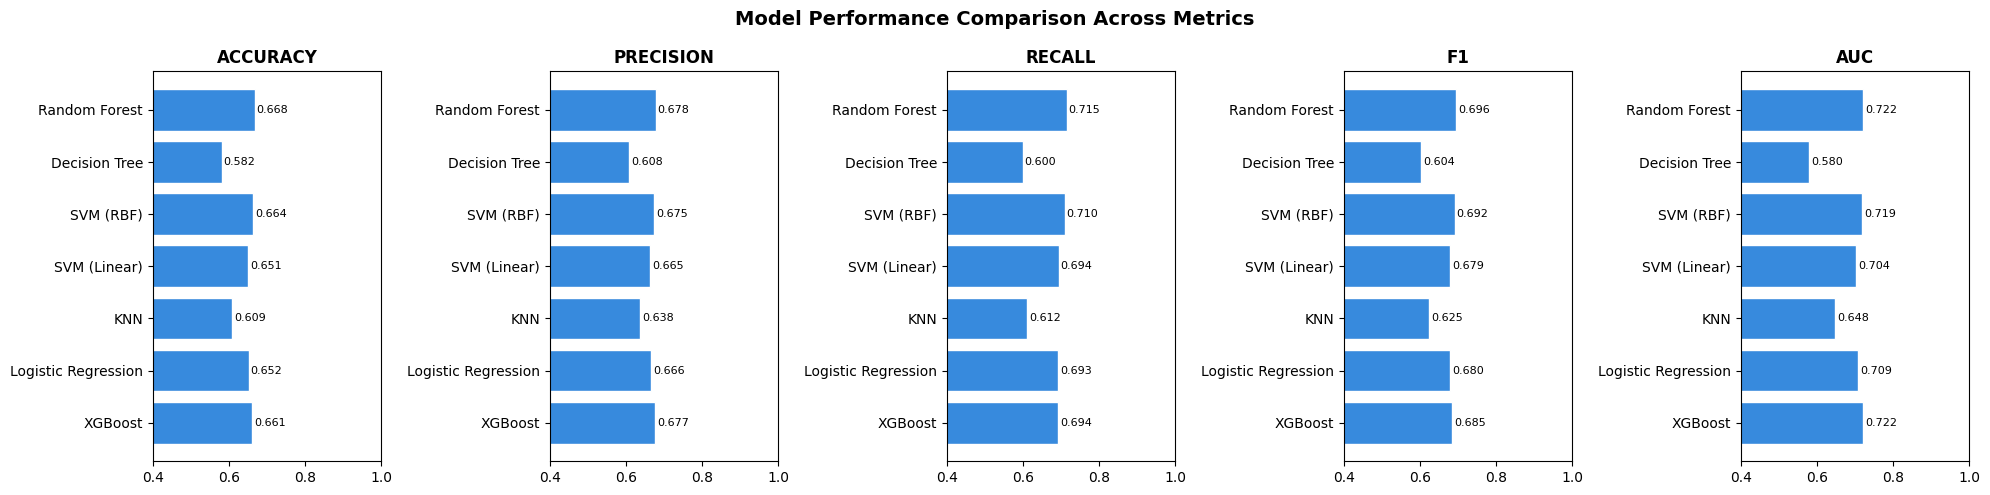

In [35]:
# Create Comparison Table
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': f"{v['accuracy']:.3f}",
        'Precision': f"{v['precision']:.3f}",
        'Recall': f"{v['recall']:.3f}",
        'F1-Score': f"{v['f1']:.3f}",
        'AUC-ROC': f"{v['auc']:.3f}",
        'Brier Score': f"{v['brier']:.3f}"}
    for name, v in results.items()  }).T

print("Model Comparison:")
print(comparison_df.to_string())

# Visual Comparison of Models
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in model_names]
    bars = axes[i].barh(
        model_names,
        values,
        color='#378ADD',
        edgecolor='white' )

    axes[i].set_title(metric.upper(), fontweight='bold')
    axes[i].set_xlim(0.4, 1.0)

    for bar, val in zip(bars, values):
        axes[i].text(
            val + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center',
            fontsize=8 )
plt.suptitle(
    'Model Performance Comparison Across Metrics',
    fontsize=14,
    fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


ROC Curves

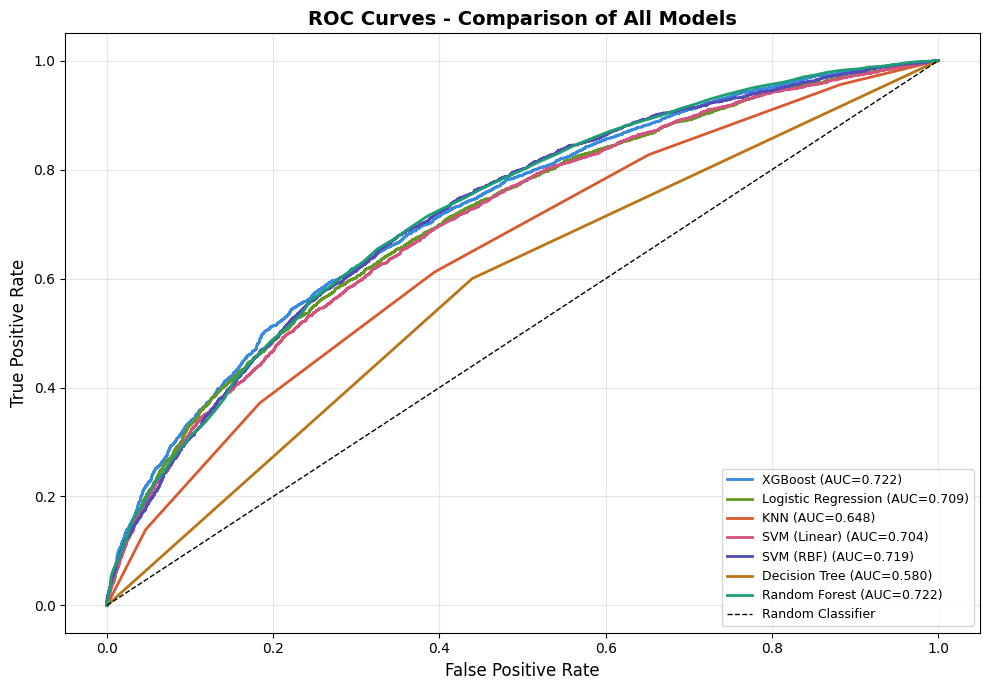

In [36]:
plt.figure(figsize=(10, 7))
colors = ['#378ADD','#639922','#D85A30','#D4537E','#534AB7','#BA7517','#1D9E75']

for (name, v), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={v['auc']:.3f})",
        color=color,
        linewidth=2  )

plt.plot([0, 1], [0, 1],
         'k--',
         label='Random Classifier',
         linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)

plt.title(
    'ROC Curves - Comparison of All Models',
    fontsize=14,
    fontweight='bold')

plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

Precision-Recall Curve

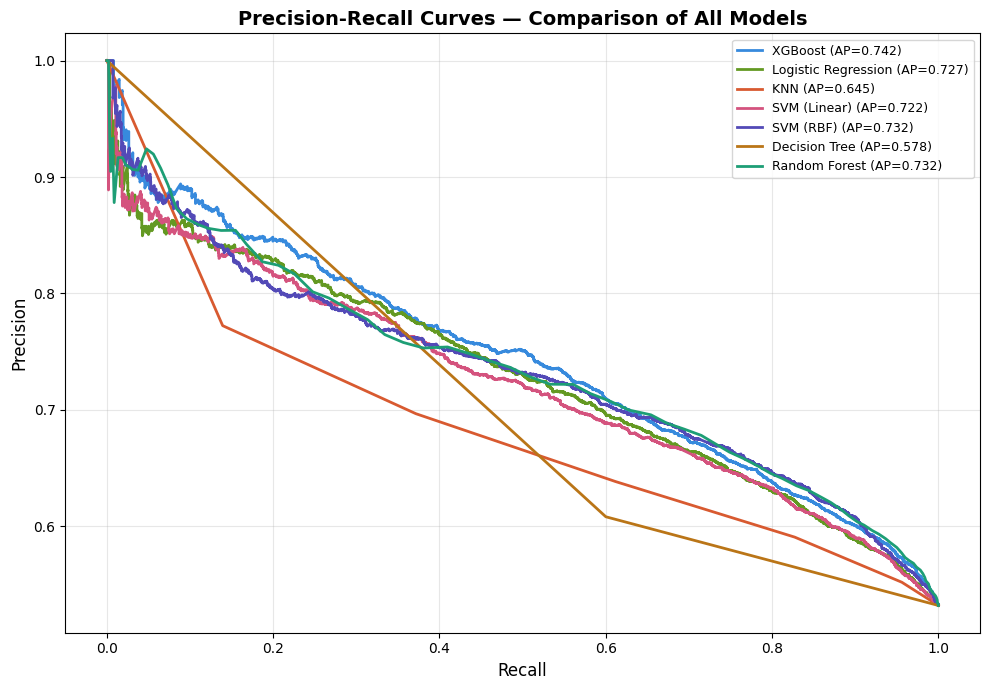

In [37]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))
colors = ['#378ADD', '#639922', '#D85A30', '#D4537E', '#534AB7', '#BA7517', '#1D9E75']

for (name, v), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, v['y_prob'])
    ap = average_precision_score(y_test, v['y_prob'])
    plt.plot(recall, precision,
             label=f"{name} (AP={ap:.3f})",
             color=color, linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — Comparison of All Models',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150)
plt.show()

Calibration Curve

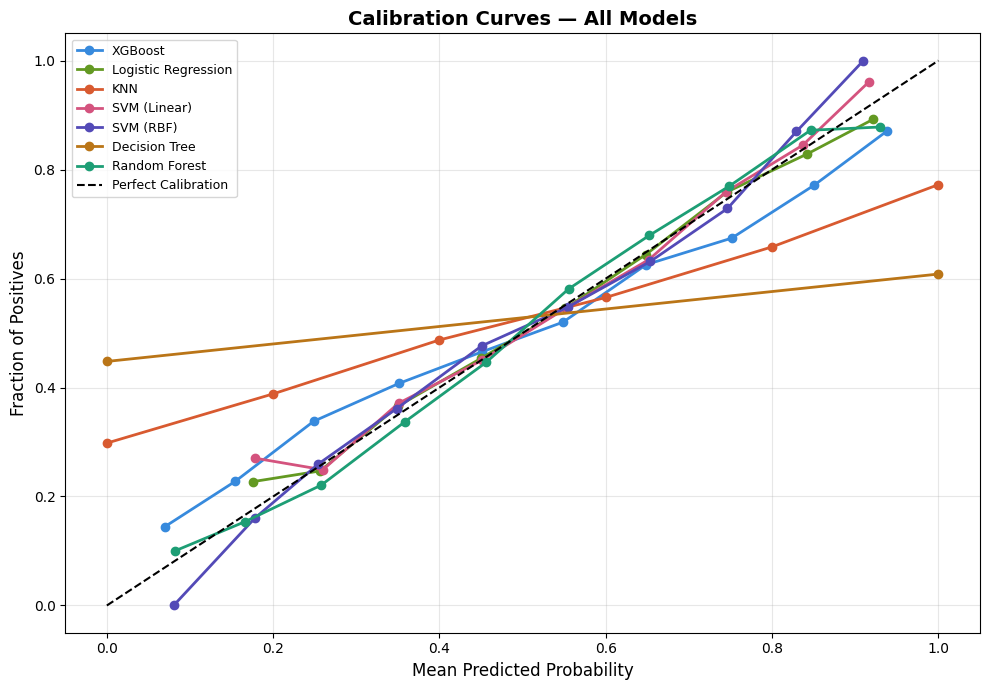

In [38]:
from sklearn.calibration import calibration_curve, CalibrationDisplay

plt.figure(figsize=(10, 7))

for (name, v), color in zip(results.items(), colors):
    prob_true, prob_pred = calibration_curve(y_test, v['y_prob'], n_bins=10)
    plt.plot(prob_pred, prob_true,
             marker='o', label=name,
             color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150)
plt.show()

MCC

XGBoost: MCC = 0.318
Logistic Regression: MCC = 0.300
KNN: MCC = 0.217
SVM (Linear): MCC = 0.298
SVM (RBF): MCC = 0.323
Decision Tree: MCC = 0.160
Random Forest: MCC = 0.331


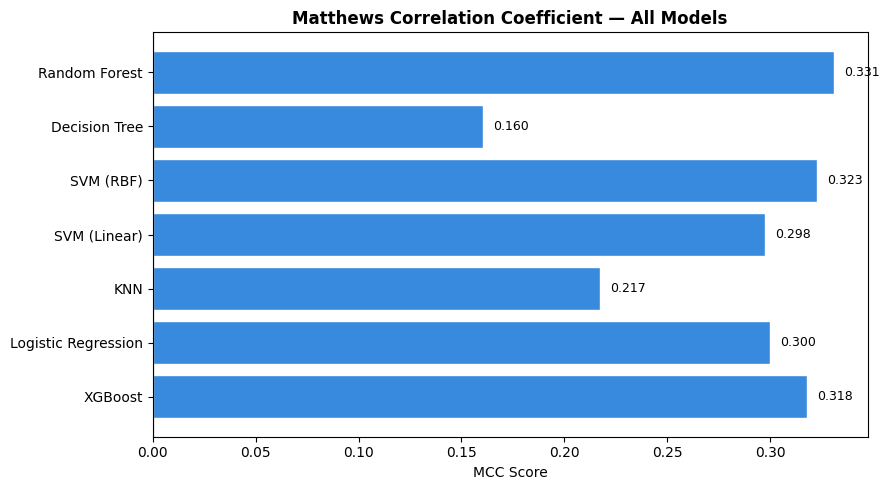

In [39]:
from sklearn.metrics import matthews_corrcoef

mcc_results = {}
for name, v in results.items():
    mcc = matthews_corrcoef(y_test, v['y_pred'])
    mcc_results[name] = mcc
    print(f"{name}: MCC = {mcc:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
names = list(mcc_results.keys())
values = list(mcc_results.values())
bars = ax.barh(names, values, color='#378ADD', edgecolor='white')
ax.set_xlabel('MCC Score')
ax.set_title('Matthews Correlation Coefficient — All Models',
             fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('mcc_comparison.png', dpi=150)
plt.show()

Best Model Selection and Evaluation

Best Model: Random Forest
F1-Score: 0.696
AUC: 0.722


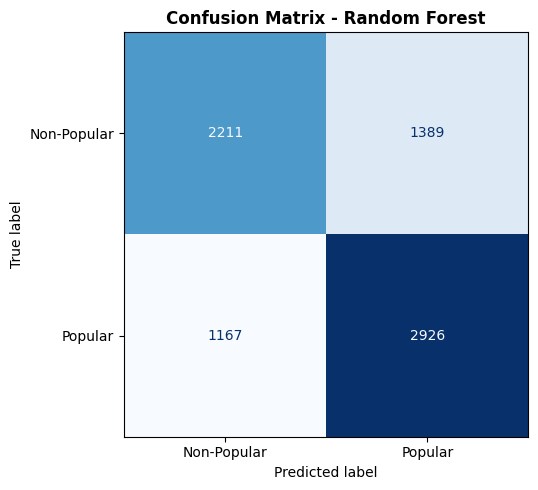


Classification Report:
              precision    recall  f1-score   support

 Non-Popular       0.65      0.61      0.63      3600
     Popular       0.68      0.71      0.70      4093

    accuracy                           0.67      7693
   macro avg       0.67      0.66      0.66      7693
weighted avg       0.67      0.67      0.67      7693



In [40]:
# Find the best model based on F1-Score
best_model_name = max(results, key=lambda x: results[x]['f1'])
best = results[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"F1-Score: {best['f1']:.3f}")
print(f"AUC: {best['auc']:.3f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best['y_pred'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Popular', 'Popular'])

disp.plot(
    ax=ax,
    colorbar=False,
    cmap='Blues')

ax.set_title(
    f'Confusion Matrix - {best_model_name}',
    fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Detailed Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best['y_pred'],
        target_names=['Non-Popular', 'Popular']
    ) )

 Learning Curve Analysis

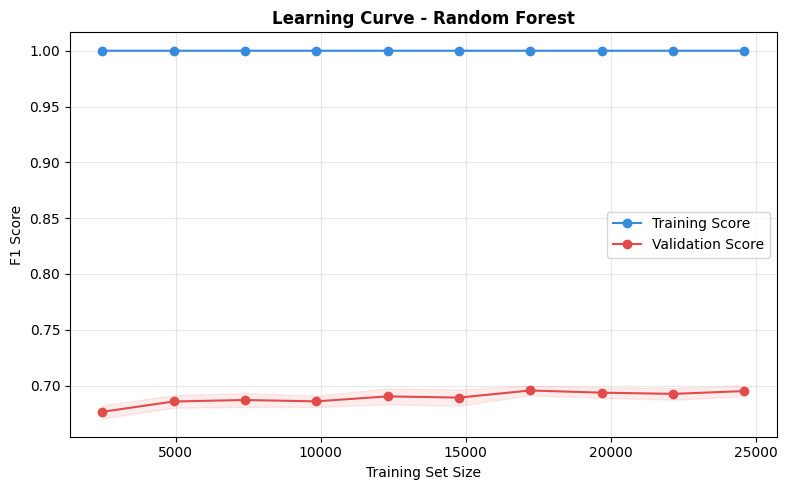

In [41]:
def plot_learning_curve(model, X, y, name, scaled=False):
    if scaled:
      X = scaler.transform(X)
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
         scoring='f1')
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='#378ADD', label='Training Score')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='#378ADD')
    plt.plot(train_sizes, val_mean, 'o-', color='#E24B4A', label='Validation Score')
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='#E24B4A')
    plt.title(f'Learning Curve - {name}', fontweight='bold')
    plt.xlabel('Training Set Size')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'learning_curve_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()

# Plot learning curve for the best model
needs_scaling = best_model_name in ['Logistic Regression', 'KNN', 'SVM (Linear)', 'SVM (RBF)']
plot_learning_curve(best['model'], X_train, y_train, best_model_name, scaled=needs_scaling)